In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import scipy.io
from os.path import isfile, join
from matplotlib import pyplot as plt
import sys
sys.path.append('..')

from IPython.display import HTML, display
from IPython.display import clear_output

def progress(value, max=100):
  return HTML("""<progress value='{value}' max='{max}', style='width: 100%'> {value} """.format(value=value, max=max))

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

%cd /content

downloaded = drive.CreateFile({'id': '18i1fknGpLGLEmC87IhkU5qeVbu9XSD-Y'})   # replace the id with id of file you want to access
downloaded.GetContentFile('pralab_db.zip')        # replace the file name with your file
!unzip pralab_db
clear_output()
print('Done! Press the Refresh button if files are not visible.')

Done! Press the Refresh button if files are not visible.


# **Data visualization**
Let's try to visualize the data contained in our db. We can choose a directory and plot one sample.

In [ ]:
img = np.load('/content/pralab/001/LEYE/ART/001_LEYE_0_0_27_0.npy')
print(img.shape)


(60, 360, 2)


We see that our data consists of 2 samples, let's plot both:

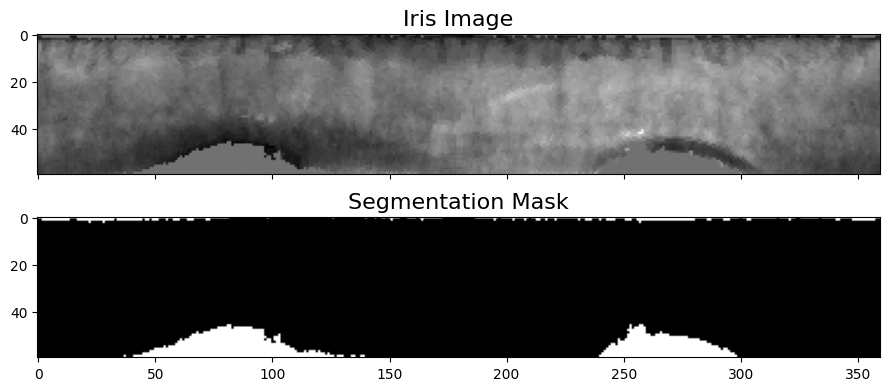

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(9, 4), sharex=True)

ax[0].imshow(img[:,:,0], cmap='gray')
ax[1].imshow(img[:,:,1], cmap='gray')

ax[0].set_title('Iris Image', fontsize=16)
ax[1].set_title('Segmentation Mask', fontsize=16)
fig.tight_layout()
plt.show()

The first one is the normalized sample of the iris.
The second one is a black and white mask, it is necessary to exclude noise from the first image

> Note: in this case we are only interested in the areas of the first image that are black in the second image

# **Upload of the BSIF Filters**

In [ ]:
# BSIF Filters download code
downloaded = drive.CreateFile({'id': '1CPk07Oqn5gmKn8yXaEns-0yZc5ZAs3Su'}) # replace the id with id of file you want to access
downloaded.GetContentFile('texturefilters.zip')  # replace the file name with your file
!unzip texturefilters
clear_output()

print('Done! Press the Refresh button if files are not visible.')

Done! Press the Refresh button if files are not visible.


# **BSIF method definition**

In [ ]:
def bsif(polar, filterpath):

    # Loading filters
    f = scipy.io.loadmat(filterpath)
    texturefilters = f.get('ICAtextureFilters')
    filter_size = texturefilters.shape[0]
    num_filters = texturefilters.shape[-1]

    polar_height = polar.shape[0]
    polar_width = polar.shape[1]

    # Wrap image
    r = int(np.floor(filter_size / 2))
    imgWrap = np.zeros((r*2+polar_height, r*2+polar_width))
    imgWrap[:r, :r] = polar[-r:, -r:]
    imgWrap[:r, r:-r] = polar[-r:, :]
    imgWrap[:r, -r:] = polar[-r:, :r]

    imgWrap[r:-r, :r] = polar[:, -r:]
    imgWrap[r:-r, r:-r] = polar
    imgWrap[r:-r, -r:] = polar[:, :r]

    imgWrap[-r:, :r] = polar[:r, -r:]
    imgWrap[-r:, r:-r] = polar[:r, :]
    imgWrap[-r:, -r:] = polar[:r, :r]

    # Loop over all BSIF kernels in the filter set
    codeBinary = np.zeros((polar_height, polar_width, num_filters))
    for i in range(1, num_filters+1):
        ci = scipy.signal.convolve2d(imgWrap, np.rot90(texturefilters[:,:,num_filters-i],2), mode='valid')
        codeBinary[:,:,i-1] = ci>0

    return codeBinary

In [ ]:
file_path = "/content/texturefilters/ICAtextureFilters_17x17_12bit.mat" #choose the filter

# **Some other functions**
We will need some other functions (we will not see them in detail).

It is just important to understand what they do in general.

In [ ]:
def bsif_dist_score(code1, code2, mask1, mask2):

    """
    This function applies the mask to extract the ROI from the iris image. Then it computes the Hamming Distance between the
    two given images.
    """

    filter_size = 17
    num_filters = 12
    max_shift = 8

    if code1 is None or mask1 is None:
        return -1., 0.
    if code2 is None or mask2 is None:
        return -2., 0.

    margin = int(np.ceil(filter_size/2))
    code1 = np.array(code1)
    code2 = np.array(code2)
    mask1 = np.array(mask1)
    mask2 = np.array(mask2)

    code1 = code1[margin:-margin, :, :]
    code2 = code2[margin:-margin, :, :]
    mask1 = mask1[margin:-margin, :]
    mask2 = mask2[margin:-margin, :]

    scoreC = np.zeros((num_filters, 2*max_shift+1))
    for shift in range(-max_shift, max_shift+1):
        andMasks = np.logical_and(mask1, np.roll(mask2, shift, axis=1))
        xorCodes = np.logical_xor(code1, np.roll(code2, shift, axis=1))
        xorCodesMasked = np.logical_and(xorCodes, np.tile(np.expand_dims(andMasks,axis=2),num_filters))
        scoreC[:,shift] = np.sum(xorCodesMasked, axis=(0,1)) / np.sum(andMasks)

    scoreMean = np.mean(scoreC, axis=0)
    scoreC = np.min(scoreMean)
    scoreC_shift = max_shift-np.argmin(scoreMean)

    return scoreC, scoreC_shift


In [ ]:
def matchingTemplate(template_extr, mask_extr, template2, mask2 ,threshold=0.38):
    """
    This function returns the hammming distance between the probe and the other image.
    """

    hm_dist = bsif_dist_score(template_extr, template2, mask_extr,mask2)[0]
    hm_dist = np.array(hm_dist)

    return  hm_dist


# **Genuine User Example**
In this example we simulate the attempt of a legitimate user to access the system.


*   We choose the ID of the user (probe).
*   We choose wich identities to include inside the system's gallery (i.e. the users that are *enrolled* in our system)

**Note**: in this case the probe id **must be included** in the gallery (since it is an enrolled user).



In [ ]:
threshold = 0.4  # Select a threshold for the distance

id_user = '001'  # SELECT PROBE
gallery = ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']  # CHOOSE WHICH IDENTITIES TO INCLUDE IN THE GALLERY

user_images = os.listdir("/content/pralab/" + id_user + "/LEYE/ART/")
user_encoding = np.load("/content/pralab/" + id_user + "/LEYE/ART/" + user_images[0])  # we just need one template

# Loading the image and the mask used as probe
arr_polar_user = user_encoding[:, :, 0]
arr_noise_user = user_encoding[:, :, 1].astype("bool")

# BSIF code extraction
template_user = bsif(arr_polar_user, file_path)

min_distances_per_user = {}

# Cycling through the gallery
for id in gallery:
    distances = []

    images = os.listdir("/content/pralab/" + id + "/LEYE/ART/")  # Getting the list of images
    images = images[1:]  # We exclude the first image in order to avoid the comparison with itself

    # Cycling through the images
    for image in images:

        # Loading the i-th image of the current ID of the gallery
        encoding = np.load("/content/pralab/" + id + "/LEYE/ART/" + image)

        # Getting the polar representation and the corresponding mask
        arr_polar = encoding[:, :, 0]
        arr_noise = encoding[:, :, 1].astype("bool")

        # Applying the BSIF
        template = bsif(arr_polar, file_path)

        # Obtaining the scores
        distance = matchingTemplate(template_user, np.logical_not(arr_noise_user), template, np.logical_not(arr_noise))
        distances.append(distance.item())  # we save each distance (4 comparisons for each user of the gallery)

    # Of the 4 distances, we just keep the smaller one
    min_distances_per_user[id] = min(distances)


Now we have a dictionary containing the smaller computed distance for each comparison of the probe with the gallery.

**ATTENTION!** This is not enough, because the distance should be smaller then our threshold.
If the distance is higher than the threshold, the user is still considered an **impostor**.

In [ ]:
min_user = min(min_distances_per_user, key=min_distances_per_user.get)  # get the id related to the smaller distance
if min_distances_per_user[min_user] <= threshold:  # if this distance is smaller or equal to the threshold
    print("GENUINE")
else:
    print("IMPOSTOR")

print(f"Min distance: {min_distances_per_user[min_user]} (threshold: {threshold})")

GENUINE
Min distance: 0.18203800246947452 (threshold: 0.4)


# **Impostor Example**
In this example we simulate the attempt of an impostor to access the system.


*   We choose the ID of the impostor (probe).
*   We choose wich identities to include inside the system's gallery (i.e. the users that are *enrolled* in our system)

> **Note**: In this case the probe id will not be included in the gallery.

In [ ]:
threshold = 0.4

id_user = '011'  # SELECT PROBE
gallery = ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']  # CHOOSE WHICH IDENTITIES TO INCLUDE IN THE GALLERY

user_images = os.listdir("/content/pralab/" + id_user + "/LEYE/ART/")
user_encoding = np.load("/content/pralab/" + id_user + "/LEYE/ART/" + user_images[0])  # we just need one template

# Loading the image and the mask used as probe
arr_polar_user = user_encoding[:, :, 0]
arr_noise_user = user_encoding[:, :, 1].astype("bool")

# BSIF code extraction
template_user = bsif(arr_polar_user, file_path)

min_distances_per_user = {}

# Cycling through the gallery
for id in gallery:
    images = os.listdir("/content/pralab/" + id + "/LEYE/ART/")
    distances = []
    images = images[1:]  # we exclude the first image in order to avoid the comparison with itself

    # Cycling through the images
    for image in images:
        # Loading the i-th image of the current ID of the gallery
        encoding = np.load("/content/pralab/" + id + "/LEYE/ART/" + image)

        # Getting the polar representation and the corresponding mask
        arr_polar = encoding[:, :, 0]
        arr_noise = encoding[:, :, 1].astype("bool")

        # Applying the BSIF
        template = bsif(arr_polar, file_path)

        # Obtaining the scores
        distance = matchingTemplate(template_user, np.logical_not(arr_noise_user), template, np.logical_not(arr_noise))
        distances.append(distance.item())  # we save each distance ( 4 comparisons for each user of the gallery)
    min_distances_per_user[id] = min(distances)  # of the 4 distances, we just keep the smaller one

In [ ]:
min_user = min(min_distances_per_user, key=min_distances_per_user.get)  # get the id related to the smaller distance

if min_distances_per_user[min_user] <= threshold:  # if this distance is smaller or equal to the threshold
    print("GENUINE")
else:
    print("IMPOSTOR")

print(f"Min distance: {min_distances_per_user[min_user]} (threshold: {threshold})")

IMPOSTOR
Min distance: 0.4449000644745326 (threshold: 0.4)
